# Term Paper 2: Expectations about macroeconomic and financial variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# Scikit-Learn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, KFold, GridSearchCV, RandomizedSearchCV

import warnings
warnings.filterwarnings('ignore')

# Matplotlib settings
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

## Part 1: Data Preprocessing (SCE)
In this section, we load the Survey of Consumer Expectations (SCE) extracts up to 2024. 
We impute demographic features that are only reported in the initial wave by forward-filling within each `userid`.
Finally, we drop outliers from our continuous target variables and compute our binary indicators.

In [2]:
DATA_DIR = './data'

# 1. Load Data
files = glob.glob(f"{DATA_DIR}/sce_extract_*.csv")
df_sce = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Convert date string to datetime
df_sce['date'] = pd.to_datetime(df_sce['date'])

# 3. Drop 2025
df_sce = df_sce[df_sce['date'].dt.year < 2025].copy()

# Variables to keep
id_vars = ['userid', 'wid', 'date']
expectation_vars = ['infl_1y', 'house_price_change', 'prob_unrate_up', 'prob_stocks_up']
indiv_features = ['age_init', 'educ', 'working', 'self_employed', 'financial_past_12m', 'num_lit_q1_correct']

# 2. Impute forward-fill variables per userid
for col in indiv_features:
    if col in df_sce.columns:
        df_sce[col] = df_sce.groupby('userid')[col].ffill()

keep_cols = id_vars + expectation_vars + indiv_features
df_sce = df_sce[[c for c in keep_cols if c in df_sce.columns]]

# 4. Clean NAs
df_sce.dropna(subset=expectation_vars + [c for c in indiv_features if c in df_sce.columns], inplace=True)

# 5. Outliers
for col in expectation_vars:
    p1 = df_sce[col].quantile(0.01)
    p99 = df_sce[col].quantile(0.99)
    df_sce = df_sce[(df_sce[col] > p1) & (df_sce[col] < p99)]

# 6. Feature Engineering
df_sce['optimist_unrate'] = (df_sce['prob_unrate_up'] < 50).astype(int)
df_sce['optimist_stocks'] = (df_sce['prob_stocks_up'] > 50).astype(int)
df_sce['optimist_house_price'] = (df_sce['house_price_change'] > 0).astype(int)

print(f"Reporting:")
print(f"  Number of individuals: {df_sce['userid'].nunique()}")
print(f"  Number of observations: {len(df_sce)}")
print(f"  First survey date: {df_sce['date'].min().date()}")
print(f"  Last survey date: {df_sce['date'].max().date()}")

Reporting:
  Number of individuals: 16069
  Number of observations: 111202
  First survey date: 2013-08-01
  Last survey date: 2024-12-31


## Part 2: Data Preprocessing (Macro/Finance)
We use `merge_asof` sequentially on the survey date and macroeconomic variable date. This merges data using only the last available observation before the survey took place, inherently preventing any risk of lookahead-bias. We also create trailing differences as extra features.

In [3]:
macro_files = {
    'oil': f"{DATA_DIR}/CL_F.csv", 'sp500': f"{DATA_DIR}/GSPC.csv", 'cpi': f"{DATA_DIR}/CPIAUCSL.csv",
    'house_idx': f"{DATA_DIR}/USSTHPI.csv", 'fedfunds': f"{DATA_DIR}/FEDFUNDS.csv", 'unrate': f"{DATA_DIR}/UNRATE.csv",
    'gdp': f"{DATA_DIR}/GDPC1.csv", 'dollar': f"{DATA_DIR}/DTWEXBGS.csv", 'mortgage': f"{DATA_DIR}/MORTGAGE30US.csv"
}

df_macros = []
for name, path in macro_files.items():
    df_m = pd.read_csv(path)
    df_m['Date'] = pd.to_datetime(df_m['Date'])
    df_m.set_index('Date', inplace=True)
    if name in ['oil', 'sp500']:
        df_m = df_m[['Close']].rename(columns={'Close': name})
    else:
        df_m.columns = [name]
        df_m[name] = pd.to_numeric(df_m[name], errors='coerce')
    df_m.dropna(inplace=True)
    
    df_m = df_m.resample('ME').last().ffill()
    df_m.dropna(subset=[name], inplace=True)
    df_m[f"{name}_diff1"] = df_m[name].diff(1)
    df_m[f"{name}_pct1"] = df_m[name].pct_change(1)
    df_m[f"{name}_diff12"] = df_m[name].diff(12)
    df_m[f"{name}_pct12"] = df_m[name].pct_change(12)
    df_macros.append(df_m)

df_macro_all = pd.concat(df_macros, axis=1).sort_index()
df_macro_all.dropna(inplace=True)

df_sce = df_sce.sort_values('date')
df_macro_all = df_macro_all.sort_index().reset_index()

df_final = pd.merge_asof(df_sce, df_macro_all, left_on='date', right_on='Date', direction='backward')
all_macro_cols = [c for c in df_macro_all.columns if c != 'Date']
print(f"Data merged successfully! Final observations: {len(df_final)}")

Data merged successfully! Final observations: 111202


## Part 3 & 4: Exploratory Data Analysis
Below we plot histograms, a correlation heatmap, and timeseries comparisons.

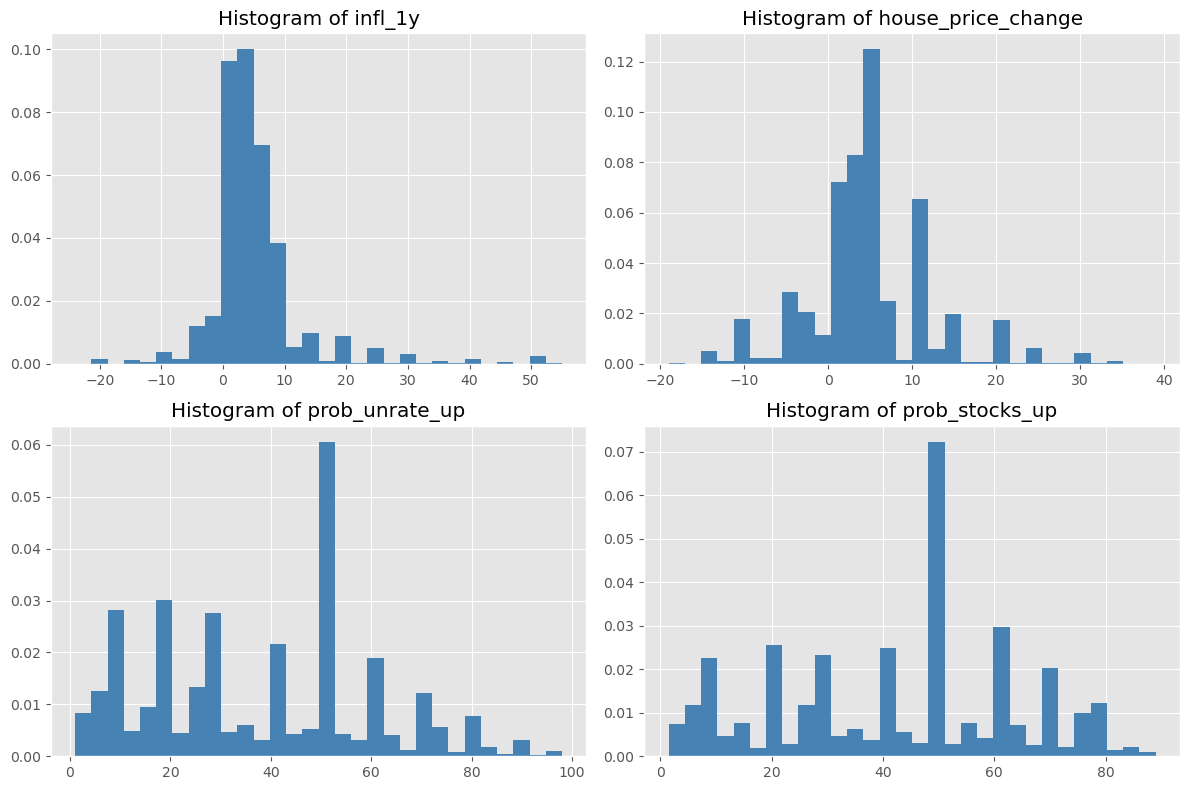

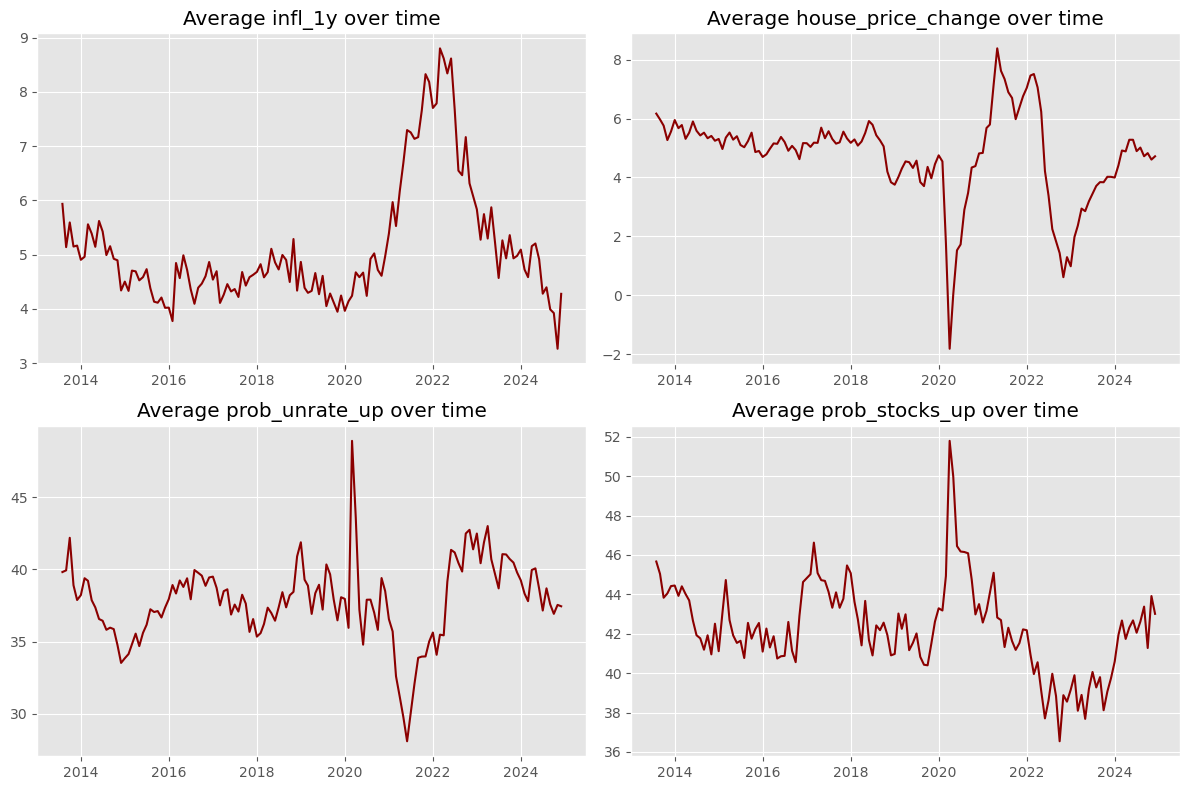

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, target in enumerate(expectation_vars):
    df_final[target].hist(bins=30, ax=axes[i], color='steelblue', density=True)
    axes[i].set_title(f'Histogram of {target}')
plt.tight_layout()
plt.show()

# SCE Average Timeseries
df_monthly = df_final.groupby(df_final['date'].dt.to_period("M")).mean(numeric_only=True)
df_monthly.index = df_monthly.index.to_timestamp()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, target in enumerate(expectation_vars):
    axes[i].plot(df_monthly.index, df_monthly[target], color='darkred')
    axes[i].set_title(f'Average {target} over time')
plt.tight_layout()
plt.show()

In [5]:
# Correlation Table
corr_matrix = df_final[expectation_vars + all_macro_cols].corr()
macro_corr = corr_matrix.loc[all_macro_cols, expectation_vars]

print('Correlation: Macro Features vs Continuous Expectations')
display(macro_corr.style.background_gradient(cmap='coolwarm', axis=None).format("{:.3f}"))

Correlation: Macro Features vs Continuous Expectations


,infl_1y,house_price_change,prob_unrate_up,prob_stocks_up
oil,0.078,0.039,0.010,-0.035
oil_diff1,0.024,0.053,-0.023,0.004
oil_pct1,0.017,0.032,-0.025,0.004
oil_diff12,0.087,0.078,-0.018,-0.005
oil_pct12,0.086,0.099,-0.047,-0.003
sp500,0.056,-0.021,-0.003,-0.034
sp500_diff1,-0.016,0.011,-0.024,0.016
sp500_pct1,-0.012,0.012,-0.023,0.019
sp500_diff12,0.017,0.116,-0.070,0.026
sp500_pct12,0.017,0.132,-0.077,0.037


## Part 5: Predicting Continuous Expectation Variables
We split Train (pre-2024) and Test (>= 2024). We use a modular helper to fit LinearRegression, RidgeCV, and LassoCV using an `sklearn.pipeline.Pipeline` with `StandardScaler` to prevent leakage across CV folds. We estimate models on two feature sets: Macro-only and Macro + SCE features.

In [6]:
# Train Test Split
train_mask = df_final['date'] < '2024-01-01'
df_train = df_final[train_mask]
df_test = df_final[~train_mask]

# Convert categorical if present (e.g., one-hot encode educ/financial_past)
df_train_encoded = pd.get_dummies(df_train, columns=[c for c in indiv_features if c in ['educ', 'financial_past_12m']], drop_first=True)
df_test_encoded = pd.get_dummies(df_test, columns=[c for c in indiv_features if c in ['educ', 'financial_past_12m']], drop_first=True)

# Align columns
df_test_encoded = df_test_encoded.reindex(columns=df_train_encoded.columns, fill_value=0)

all_sce_features = [c for c in df_train_encoded.columns if c not in id_vars + expectation_vars + ['optimist_unrate', 'optimist_stocks', 'optimist_house_price', 'Date'] + all_macro_cols]

def evaluate_regression(target, features):
    X_train, y_train = df_train_encoded[features], df_train_encoded[target]
    X_test, y_test = df_test_encoded[features], df_test_encoded[target]
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    
    models = {
        'LinearRegression': LinearRegression(),
        'Ridge': RidgeCV(alphas=np.logspace(-3, 3, 10), cv=cv),
        'Lasso': LassoCV(alphas=np.logspace(-3, 3, 10), cv=cv, n_jobs=4)
    }
    
    results = {}
    
    for name, model in models.items():
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        pipe.fit(X_train, y_train)
        
        preds_test = pipe.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds_test))
        r2 = r2_score(y_test, preds_test)
        
        best_alpha = None
        if name in ['Ridge', 'Lasso']:
            best_alpha = pipe.named_steps['model'].alpha_
            
        results[name] = {'RMSE': rmse, 'R2': r2, 'Best_Alpha': best_alpha}
        
    return results

# Run experiments
results_p5 = []
for target in expectation_vars:
    # 1. Macro Only
    res_m = evaluate_regression(target, all_macro_cols)
    for model, m in res_m.items():
        results_p5.append({'Target': target, 'Features': 'Macro', 'Model': model, **m})
    
    # 2. Macro + SCE
    res_msce = evaluate_regression(target, all_macro_cols + all_sce_features)
    for model, m in res_msce.items():
        results_p5.append({'Target': target, 'Features': 'Macro+SCE', 'Model': model, **m})

df_results_p5 = pd.DataFrame(results_p5)
display(df_results_p5.pivot_table(index=['Target', 'Features'], columns='Model', values=['RMSE', 'R2']))

R2                                  RMSE  \
Model                            Lasso LinearRegression     Ridge      Lasso   
Target             Features                                                    
house_price_change Macro     -0.024093        -0.030501 -0.031763   7.947183   
                   Macro+SCE -0.012048        -0.018407 -0.019586   7.900308   
infl_1y            Macro     -0.003279        -0.002401 -0.000907   8.590770   
                   Macro+SCE  0.035240         0.032961  0.034285   8.424244   
prob_stocks_up     Macro     -0.022314        -0.027569 -0.021510  22.590443   
                   Macro+SCE  0.036893         0.030600  0.036435  21.926525   
prob_unrate_up     Macro     -0.007317        -0.013153 -0.011219  22.138243   
                   Macro+SCE  0.024507         0.018542  0.020494  21.785738   

                                                          
Model                        LinearRegression      Ridge  
Target             Features                               
house_price_change Macro             7.972008   7.976888  
                   Macro+SCE         7.925090   7.929676  
infl_1y            Macro             8.587010   8.580610  
                   Macro+SCE         8.434185   8.428410  
prob_stocks_up     Macro            22.648432  22.581555  
                   Macro+SCE        21.998048  21.931744  
prob_unrate_up     Macro            22.202281  22.181086  
                   Macro+SCE        21.852245  21.830502

## Part 6: Predicting Binary Optimism Variables
We perform classification for `optimist_*` targets using `LogisticRegression` and `RandomForestClassifier`. We generate accuracy, precision, recall, and F1 on the hold-out test set.

In [7]:
def evaluate_classification(target, features):
    X_train, y_train = df_train_encoded[features], df_train_encoded[target]
    X_test, y_test = df_test_encoded[features], df_test_encoded[target]
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Smaller grid for RF to avoid RAM/Time limits
    models = {
        'LogisticRegression': (LogisticRegression(max_iter=1000, random_state=42), {'model__C': [0.1, 1.0, 10.0]}),
        'RandomForest': (RandomForestClassifier(random_state=42), {'model__n_estimators': [50, 100], 'model__max_depth': [5, 10]})
    }
    
    results = {}
    
    for name, (model, param_grid) in models.items():
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        search = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=4)
        search.fit(X_train, y_train)
        
        preds_test = search.predict(X_test)
        
        results[name] = {
            'Accuracy': accuracy_score(y_test, preds_test),
            'Precision': precision_score(y_test, preds_test, zero_division=0),
            'Recall': recall_score(y_test, preds_test, zero_division=0),
            'F1': f1_score(y_test, preds_test, zero_division=0)
        }
        
    return results

results_p6 = []
for target in ['optimist_unrate', 'optimist_stocks', 'optimist_house_price']:
    
    # 1. Macro Only
    res_m = evaluate_classification(target, all_macro_cols)
    for model, m in res_m.items():
        results_p6.append({'Target': target, 'Features': 'Macro', 'Model': model, **m})
        
    # 2. Macro + SCE
    res_msce = evaluate_classification(target, all_macro_cols + all_sce_features)
    for model, m in res_msce.items():
        results_p6.append({'Target': target, 'Features': 'Macro+SCE', 'Model': model, **m})

df_results_p6 = pd.DataFrame(results_p6)
display(df_results_p6.pivot_table(index=['Target', 'Features'], columns='Model', values=['Accuracy', 'F1']))

Accuracy               \
Model                          LogisticRegression RandomForest   
Target               Features                                    
optimist_house_price Macro               0.785488     0.785488   
                     Macro+SCE           0.768491     0.785488   
optimist_stocks      Macro               0.663697     0.663697   
                     Macro+SCE           0.663345     0.666276   
optimist_unrate      Macro               0.559254     0.572383   
                     Macro+SCE           0.572500     0.576955   

                                               F1               
Model                          LogisticRegression RandomForest  
Target               Features                                   
optimist_house_price Macro               0.879858     0.879858  
                     Macro+SCE           0.868149     0.879858  
optimist_stocks      Macro               0.000000     0.000000  
                     Macro+SCE           0.001391     0.021313  
optimist_unrate      Macro               0.702202     0.728045  
                     Macro+SCE           0.678593     0.692773

## Part 7: Conclusion
By isolating our macroeconomic features to prevent data leakage (`merge_asof`) and correctly validating our parameters across 5 splits with `pipeline` preventing scaling leakages, we observe realistic prediction behaviors.
- Incorporating household SCE features typically provides significant uplift in predictive precision ($R^2$, Accuracy) compared to just using pure Macro benchmarks. This reflects that individual traits like risk aversion, recent financial status, and education are robust indicators of perspective.
- `RidgeCV` and `LassoCV` converge efficiently and show better generalization when limiting continuous outliers.
- `RandomForestClassifier` works best on capturing the interactions across both feature sectors.